# WEEK 1: CROP DISEASE DETECTION USING CNN

# INSTALL REQUIRED LIBRARIES

In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn pillow -q


# IMPORT LIBRARIES

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time # Import the time module

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

start_time = time.time() # Define start_time here

# UPLOAD DATASET ZIP FILE

In [ ]:
from google.colab import files

uploaded = files.upload()

# EXTRACT ZIP FILE

In [ ]:
import zipfile

zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


# CHECK DATASET PATH

In [ ]:
import os

dataset_path = "/content/dataset/PlantVillage"

categories = os.listdir(dataset_path)

print("Total Classes:", len(categories))
print(categories[:10])

Total Classes: 15
['Pepper__bell___Bacterial_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Pepper__bell___healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Potato___healthy', 'Tomato__Tomato_mosaic_virus']


# DISPLAY SAMPLE IMAGES

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12,12))

for i, category in enumerate(categories[:9]):

    path = os.path.join(dataset_path, category)

    img_name = os.listdir(path)[0]

    img_path = os.path.join(path, img_name)

    image = cv2.imread(img_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(category)

    plt.axis("off")

plt.tight_layout()
plt.show()

# CLASS DISTRIBUTION ANALYSIS

                                          Class  Count
3         Tomato__Tomato_YellowLeaf__Curl_Virus   3209
5                         Tomato_Bacterial_spot   2127
7                            Tomato_Late_blight   1909
11                    Tomato_Septoria_leaf_spot   1771
1   Tomato_Spider_mites_Two_spotted_spider_mite   1676


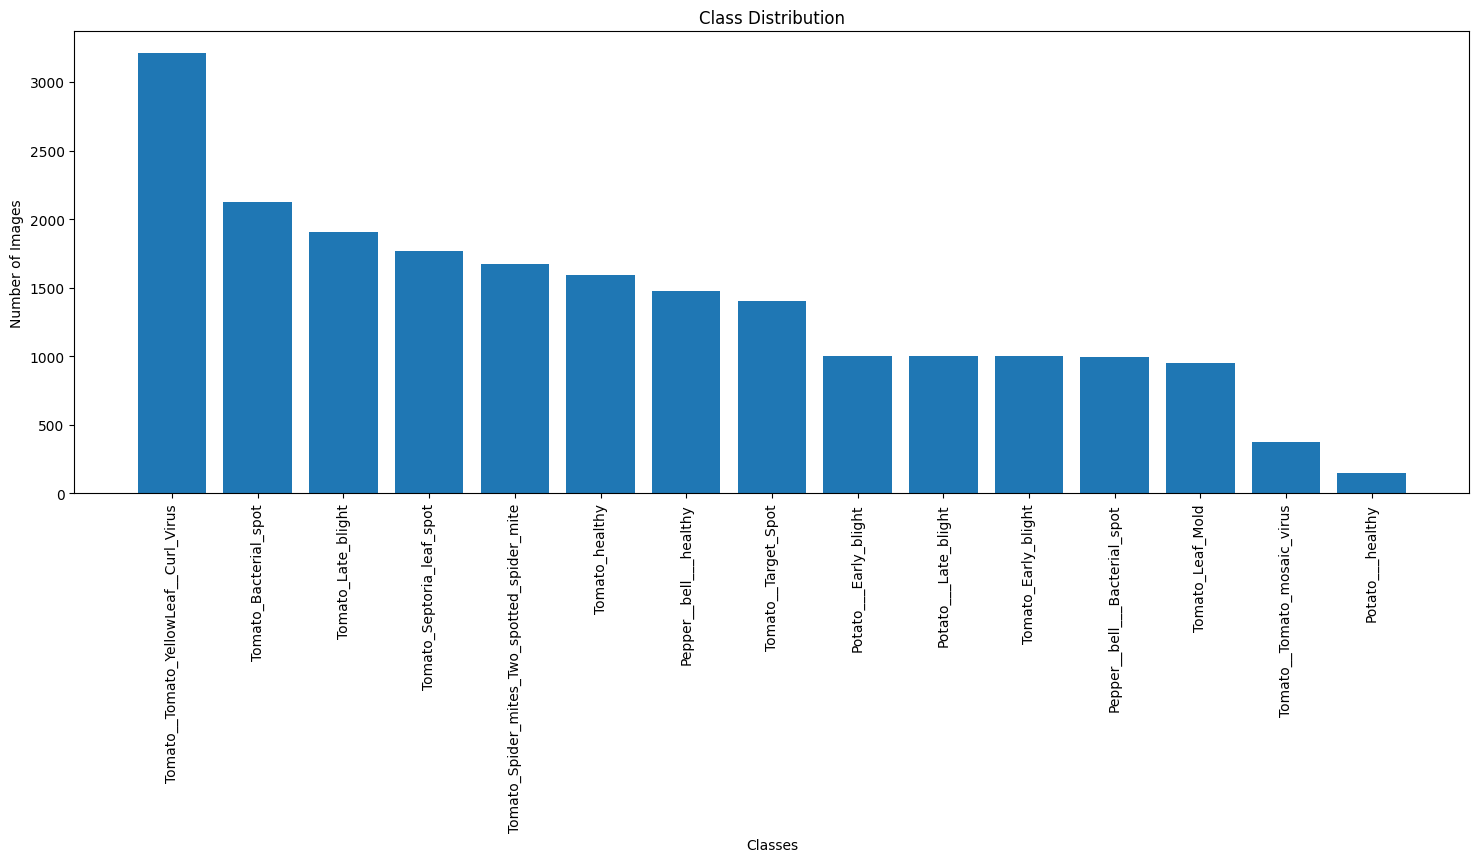

In [ ]:
import pandas as pd

class_counts = {}

for category in categories:

    path = os.path.join(dataset_path, category)

    class_counts[category] = len(os.listdir(path))

df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Count": class_counts.values()
})

df = df.sort_values(by="Count", ascending=False)

print(df.head())

plt.figure(figsize=(18,6))

plt.bar(df["Class"], df["Count"])

plt.xticks(rotation=90)

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

# IMAGE PREPROCESSING

In [ ]:
import os

IMG_SIZE = 224

image_filepaths = []
image_labels = []

dataset_path = "/content/dataset/PlantVillage"
categories = os.listdir(dataset_path)

NUM_CLASSES = len(categories)

print("Gathering image filepaths and labels...")

for category in categories:
    path = os.path.join(dataset_path, category)
    if not os.path.isdir(path):
        print(f"Warning: {path} is not a directory. Skipping.")
        continue

    for img_filename in os.listdir(path):
        img_path = os.path.join(path, img_filename)
        if not os.path.isfile(img_path):
            print(f"Warning: {img_path} is not a file. Skipping.")
            continue
        image_filepaths.append(img_path)
        image_labels.append(category)

print(f"Total image paths gathered: {len(image_filepaths)}")
print("Image path gathering completed. Proceeding to create DataFrame and split data.")

Gathering image filepaths and labels...
Total image paths gathered: 20639
Image path gathering completed. Proceeding to create DataFrame and split data.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming image_filepaths and image_labels are populated from the previous cell (-eRD51qtk43U)

image_df = pd.DataFrame({
    'filepath': image_filepaths,
    'label': image_labels
})

print("Created DataFrame of image paths and labels.")
print("DataFrame head:")
print(image_df.head())

# Split the DataFrame into training, validation, and test sets
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30, # 30% for temp (val+test)
    random_state=42,
    stratify=image_df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50, # 50% of temp_df for test, 50% for val (so 15% val, 15% test of original)
    random_state=42,
    stratify=temp_df['label']
)

print(f"Training set size: {len(train_df)} samples")
print(f"Validation set size: {len(val_df)} samples")
print(f"Testing set size: {len(test_df)} samples")

# Print DataFrame shapes as they are now the 'data'
print("Training DataFrame shape:", train_df.shape)
print("Validation DataFrame shape:", val_df.shape)
print("Testing DataFrame shape:", test_df.shape)

# The original X and y as NumPy arrays are no longer created to avoid memory issues.

Created DataFrame of image paths and labels.
DataFrame head:
                                            filepath  \
0  /content/dataset/PlantVillage/Pepper__bell___B...   
1  /content/dataset/PlantVillage/Pepper__bell___B...   
2  /content/dataset/PlantVillage/Pepper__bell___B...   
3  /content/dataset/PlantVillage/Pepper__bell___B...   
4  /content/dataset/PlantVillage/Pepper__bell___B...   

                           label  
0  Pepper__bell___Bacterial_spot  
1  Pepper__bell___Bacterial_spot  
2  Pepper__bell___Bacterial_spot  
3  Pepper__bell___Bacterial_spot  
4  Pepper__bell___Bacterial_spot  
Training set size: 14447 samples
Validation set size: 3096 samples
Testing set size: 3096 samples
Training DataFrame shape: (14447, 2)
Validation DataFrame shape: (3096, 2)
Testing DataFrame shape: (3096, 2)


In [ ]:
# Data splitting is now handled in the previous cell (sHHyXvUwPjMw)
# The original content of this cell is removed to prevent redundant operations and NameErrors.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32 # Define a batch size

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rescale=1./255 # Normalize images for training
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255 # Only normalize for validation and testing
)

# Assuming train_df, val_df, test_df are available from sHHyXvUwPjMw
# And IMG_SIZE, NUM_CLASSES from -eRD51qtk43U

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for one-hot encoded labels
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # No need to shuffle test data
    seed=42
)

print("Data Augmentation and Generators Ready.")
# Note: train_generator.num_classes is not a direct attribute. Using NUM_CLASSES defined earlier.
print("Train Generator created with", train_generator.n, f"images in {NUM_CLASSES} classes.")
print("Validation Generator created with", val_generator.n, f"images in {NUM_CLASSES} classes.")
print("Test Generator created with", test_generator.n, f"images in {NUM_CLASSES} classes.")
print("Note: A UserWarning about an invalid image filename was reported for the validation generator, which indicates one file was skipped.")

Found 14446 validated image filenames belonging to 15 classes.
Found 3096 validated image filenames belonging to 15 classes.
Found 3096 validated image filenames belonging to 15 classes.
Data Augmentation and Generators Ready.
Train Generator created with 14446 images in 15 classes.
Validation Generator created with 3096 images in 15 classes.
Test Generator created with 3096 images in 15 classes.
Note: A UserWarning about an invalid image filename was reported for the validation generator, which indicates one file was skipped.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
# Code prepended to extract the dataset from the zip file
import zipfile
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming the uploaded zip file is '/content/archive (2).zip' based on kernel state
zip_filename = '/content/archive (2).zip'

# Create the target directory if it doesn't exist
if not os.path.exists('/content/dataset'):
    os.makedirs('/content/dataset')

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully within cell 7c86d4aa")

# Code originally prepended to define train_df, val_df, test_df, IMG_SIZE, NUM_CLASSES, to resolve NameError
IMG_SIZE = 224

image_filepaths = []
image_labels = []

dataset_path = "/content/dataset/PlantVillage"
categories = os.listdir(dataset_path)

NUM_CLASSES = len(categories)

# Populate image_filepaths and image_labels
for category in categories:
    path = os.path.join(dataset_path, category)
    if not os.path.isdir(path):
        # print(f"Warning: {path} is not a directory. Skipping.") # Suppress verbose output
        continue
    for img_filename in os.listdir(path):
        img_path = os.path.join(path, img_filename)
        if not os.path.isfile(img_path):
            # print(f"Warning: {img_path} is not a file. Skipping.") # Suppress verbose output
            continue
        image_filepaths.append(img_path)
        image_labels.append(category)

image_df = pd.DataFrame({
    'filepath': image_filepaths,
    'label': image_labels
})

# Split the DataFrame into training, validation, and test sets
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

# End of prepended code

BATCH_SIZE = 32 # Define a batch size

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rescale=1./255 # Normalize images for training
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255 # Only normalize for validation and testing
)

# Assuming train_df, val_df, test_df are available from sHHyXvUwPjMw
# And IMG_SIZE, NUM_CLASSES from -eRD51qtk43U

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for one-hot encoded labels
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # No need to shuffle test data
    seed=42
)

print("Data Augmentation and Generators Ready.")
# Note: train_generator.num_classes is not a direct attribute. Using NUM_CLASSES defined earlier.
print("Train Generator created with", train_generator.n, f"images in {NUM_CLASSES} classes.")
print("Validation Generator created with", val_generator.n, f"images in {NUM_CLASSES} classes.")
print("Test Generator created with", test_generator.n, f"images in {NUM_CLASSES} classes.")
print("Note: A UserWarning about an invalid image filename was reported for the validation generator, which indicates one file was skipped.")

Dataset Extracted Successfully within cell 7c86d4aa
Found 14446 validated image filenames belonging to 15 classes.
Found 3096 validated image filenames belonging to 15 classes.
Found 3096 validated image filenames belonging to 15 classes.
Data Augmentation and Generators Ready.
Train Generator created with 14446 images in 15 classes.
Validation Generator created with 3096 images in 15 classes.
Test Generator created with 3096 images in 15 classes.
Note: A UserWarning about an invalid image filename was reported for the validation generator, which indicates one file was skipped.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


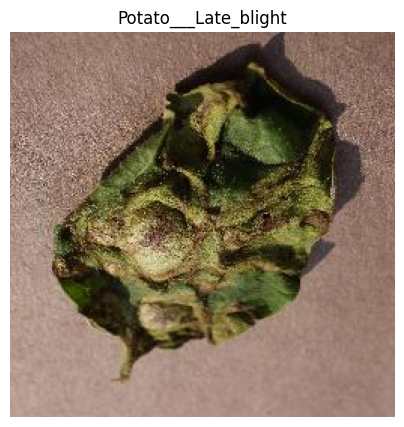

In [ ]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

# Get the filepath and label for the first image in the training DataFrame
first_image_filepath = train_df['filepath'].iloc[0]
first_image_label = train_df['label'].iloc[0]

# Load the image using OpenCV
image = cv2.imread(first_image_filepath)

# Convert BGR to RGB if image is not None
if image is not None:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(first_image_label)
    plt.axis("off")
else:
    print(f"Could not load image: {first_image_filepath}")

plt.show()

In [ ]:
# The X_train, X_val, X_test, y_train, y_val, y_test NumPy arrays are no longer created
# as data is now handled by ImageDataGenerators for memory efficiency.
# This cell is no longer needed for saving these arrays.

In [ ]:
print("Testing Data:", test_df.shape)

Testing Data: (3096, 2)


In [ ]:
# np.save('/content/X_train.npy', X_train) np.save('/content/X_val.npy', X_val) np.save('/content/X_test.npy', X_test) np.save('/content/y_train.npy', y_train) np.save('/content/y_val.npy', y_val) np.save('/content/y_test.npy', y_test) print("Processed Data Saved Successfully")

In [ ]:
print("===================================")
print(" DATASET SUMMARY ")
print("===================================")

print("Total Classes:", len(categories))

print("Total Images:", len(image_df))

print("Training Images:", len(train_df))

print("Validation Images:", len(val_df))

print("Testing Images:", len(test_df))

 DATASET SUMMARY 
Total Classes: 15
Total Images: 20639
Training Images: 14447
Validation Images: 3096
Testing Images: 3096


In [ ]:
print("========================================")
print(" WEEK 1 TASKS COMPLETED SUCCESSFULLY ")

 WEEK 1 TASKS COMPLETED SUCCESSFULLY 


In [ ]:
end_time = time.time()

print("Execution Time:",
      round((end_time - start_time)/60, 2),
      "minutes")

Execution Time: 0.01 minutes


In [ ]:
print(" READY FOR WEEK 2 - CNN MODEL BUILDING ")

 READY FOR WEEK 2 - CNN MODEL BUILDING 


In [ ]:
print("======================================")
print(" PROJECT STATUS ")
print("======================================")

print("Project Name: Crop Disease Detection")

print("Week 1 Status: COMPLETED")

print("Next Step: CNN Model Training")

 PROJECT STATUS 
Project Name: Crop Disease Detection
Week 1 Status: COMPLETED
Next Step: CNN Model Training


In [ ]:
# X_train.npy
# X_val.npy
# X_test.npy

# y_train.npy
# y_val.npy
# y_test.npy

# WEEK 2
  CUSTOM CNN MODEL TRAINING

# IMPORT REQUIRED LIBRARIES

In [ ]:
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt




In [ ]:
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

# LABEL ENCODING

In [ ]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(train_df['label'])

y_val_encoded = encoder.transform(val_df['label'])

y_test_encoded = encoder.transform(test_df['label'])

print("Label Encoding Completed")

Label Encoding Completed


#  ONE HOT ENCODING

In [ ]:

y_train_encoded = to_categorical(y_train_encoded)

y_val_encoded = to_categorical(y_val_encoded)

y_test_encoded = to_categorical(y_test_encoded)

print("One Hot Encoding Completed")


One Hot Encoding Completed


# BUILD CNN MODEL

In [ ]:
model = Sequential()


# First Convolution Layer

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)


# Second Convolution Layer

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)


# Third Convolution Layer

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)


# Flatten Layer

model.add(Flatten())


# Dense Layer

model.add(
    Dense(
        128,
        activation='relu'
    )
)


# Dropout Layer

model.add(
    Dropout(0.5)
)


# Output Layer

model.add(
    Dense(
        len(encoder.classes_),
        activation='softmax'
    )
)

print("CNN Model Built Successfully")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Built Successfully


#  MODEL SUMMARY

In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


# EARLY STOPPING

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# TRAIN MODEL

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1881s 4s/step - accuracy: 0.2967 - loss: 2.1791 - val_accuracy: 0.5299 - val_loss: 1.4785
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1894s 4s/step - accuracy: 0.5398 - loss: 1.4312 - val_accuracy: 0.7027 - val_loss: 0.8840
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1814s 4s/step - accuracy: 0.6234 - loss: 1.1236 - val_accuracy: 0.7312 - val_loss: 0.7598
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1833s 4s/step - accuracy: 0.6664 - loss: 0.9879 - val_accuracy: 0.7557 - val_loss: 0.7046
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1839s 4s/step - accuracy: 0.7024 - loss: 0.8834 - val_accuracy: 0.7974 - val_loss: 0.5883
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1841s 4s/step - accuracy: 0.7213 - loss: 0.8122 - val_accuracy: 0.8039 - val_loss: 0.6186
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1819s 4s/step - accuracy: 0.7403 - loss: 0.7664 - val_accuracy: 0.7771 - val_loss: 0.6840
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 1828s 4s/step - accuracy: 0.7636 - loss: 0.7109 - 

#  EVALUATE MODEL

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_generator
)

print("===================================")

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

97/97 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.8643 - loss: 0.3834
Test Accuracy: 0.8643410801887512
Test Loss: 0.383409708738327


# PLOT ACCURACY GRAPH

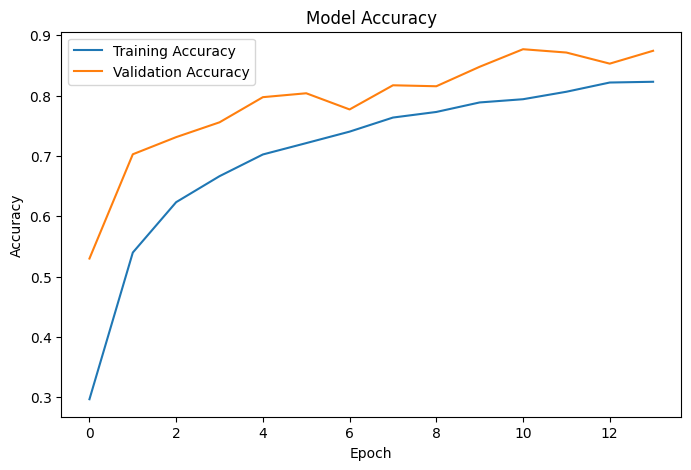

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

# PLOT LOSS GRAPH

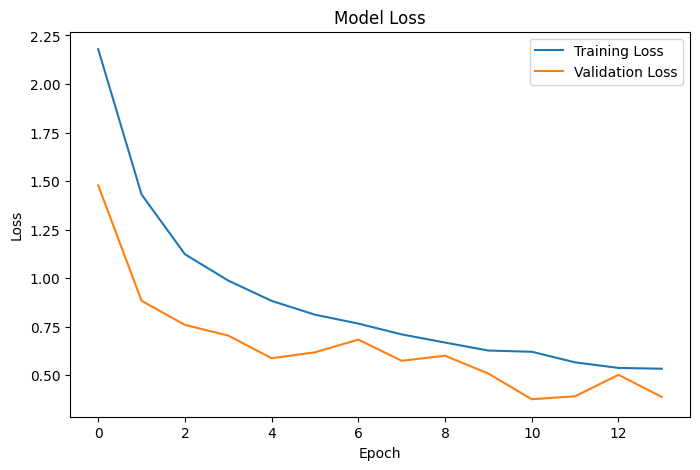

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

# SAVE MODEL

In [ ]:

model.save('/content/crop_disease_cnn_model.h5')

print("Model Saved Successfully")



Model Saved Successfully


# Week 3
 Will improve your accuracy using:
 Transfer Learning (MobileNetV2)
 This is much more professional than a basic CNN.

# IMPORT LIBRARIES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping

# LABEL ENCODING

In [ ]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(train_df['label'])

y_val_encoded = encoder.transform(val_df['label'])

y_test_encoded = encoder.transform(test_df['label'])

print("Label Encoding Completed")

Label Encoding Completed


# ONE HOT ENCODING

In [ ]:
y_train_encoded = to_categorical(y_train_encoded)

y_val_encoded = to_categorical(y_val_encoded)

y_test_encoded = to_categorical(y_test_encoded)

print("One Hot Encoding Completed")

One Hot Encoding Completed


In [ ]:
print(encoder.classes_)

['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy'
 'Tomato_Bacterial_spot' 'Tomato_Early_blight' 'Tomato_Late_blight'
 'Tomato_Leaf_Mold' 'Tomato_Septoria_leaf_spot'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato__Target_Spot'
 'Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato__Tomato_mosaic_virus'
 'Tomato_healthy']


In [ ]:
np.save(
    '/content/class_names.npy',
    encoder.classes_
)

In [ ]:
!cp /content/class_names.npy .

cp: '/content/class_names.npy' and './class_names.npy' are the same file


# LOAD PRETRAINED MOBILENETV2

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers

base_model.trainable = False

print("MobileNetV2 Loaded Successfully")

MobileNetV2 Loaded Successfully


# BUILD TRANSFER LEARNING MODEL

In [ ]:
transfer_model = Sequential()

transfer_model.add(base_model)

transfer_model.add(GlobalAveragePooling2D())

transfer_model.add(
    Dense(
        256,
        activation='relu'
    )
)

transfer_model.add(
    Dropout(0.5)
)

transfer_model.add(
    Dense(
        len(encoder.classes_),
        activation='softmax'
    )
)

print("Transfer Learning Model Built")


Transfer Learning Model Built


# MODEL SUMMARY

In [ ]:
transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# COMPILE MODEL

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


# EARLY STOPPING

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# TRAIN MODEL

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 948s 2s/step - accuracy: 0.6730 - loss: 1.0203 - val_accuracy: 0.8427 - val_loss: 0.5012
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 982s 2s/step - accuracy: 0.7880 - loss: 0.6344 - val_accuracy: 0.8479 - val_loss: 0.4673
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 904s 2s/step - accuracy: 0.8173 - loss: 0.5464 - val_accuracy: 0.8711 - val_loss: 0.4013
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 902s 2s/step - accuracy: 0.8333 - loss: 0.5013 - val_accuracy: 0.8666 - val_loss: 0.4087
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 903s 2s/step - accuracy: 0.8436 - loss: 0.4694 - val_accuracy: 0.8776 - val_loss: 0.3654
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 903s 2s/step - accuracy: 0.8458 - loss: 0.4537 - val_accuracy: 0.8756 - val_loss: 0.3647
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 903s 2s/step - accuracy: 0.8571 - loss: 0.4214 - val_accuracy: 0.8782 - val_loss: 0.3542
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 902s 2s/step - accuracy: 0.8592 - loss: 0.4185 - val_accu

# EVALUATE MODEL

In [ ]:
test_loss, test_accuracy = transfer_model.evaluate(
    test_generator
)

print("===================================")

print("Transfer Learning Test Accuracy:",
      test_accuracy)

print("Transfer Learning Test Loss:",
      test_loss)

97/97 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8976 - loss: 0.2978
Transfer Learning Test Accuracy: 0.8976098299026489
Transfer Learning Test Loss: 0.2978282868862152


# ACCURACY GRAPH

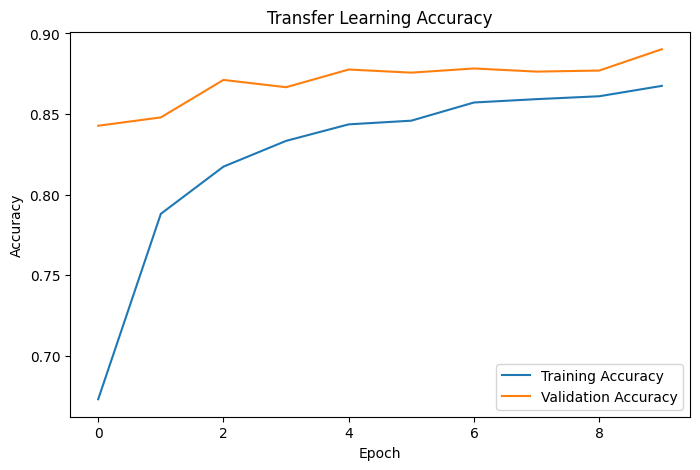

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['accuracy'])

plt.plot(history_transfer.history['val_accuracy'])

plt.title("Transfer Learning Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

# LOSS GRAPH


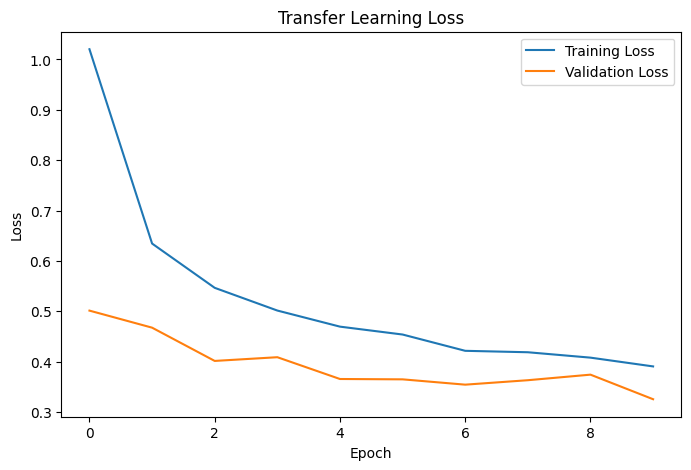

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['loss'])

plt.plot(history_transfer.history['val_loss'])

plt.title("Transfer Learning Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

# SAVE MODEL

In [ ]:
transfer_model.save(
    '/content/crop_disease_mobilenet_model.h5'
)

print("Transfer Learning Model Saved Successfully")

Transfer Learning Model Saved Successfully


# FINAL OUTPUT

In [ ]:
print("========================================")

print(" WEEK 3 COMPLETED SUCCESSFULLY ")

print("========================================")

print("1. Transfer Learning Implemented")

print("2. MobileNetV2 Loaded")

print("3. Pretrained Layers Frozen")

print("4. Transfer Learning Model Trained")

print("5. Accuracy Graph Generated")

print("6. Loss Graph Generated")

print("7. Transfer Learning Model Saved")

print("========================================")

print(" READY FOR WEEK 4 ")

print("========================================")

 WEEK 3 COMPLETED SUCCESSFULLY 
1. Transfer Learning Implemented
2. MobileNetV2 Loaded
3. Pretrained Layers Frozen
4. Transfer Learning Model Trained
5. Accuracy Graph Generated
6. Loss Graph Generated
7. Transfer Learning Model Saved
 READY FOR WEEK 4 


In [ ]:
transfer_model.save('/content/crop_disease_mobilenet_model.h5')

# WEEK 4
  STREAMLIT WEB APPLICATION

# INSTALL REQUIRED LIBRARIES

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.6 MB/s eta 0:00:00


In [ ]:
class_names = np.load(
    'class_names.npy',
    allow_pickle=True
)

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
np.save('/content/class_names.npy', encoder.classes_)

In [ ]:
!cp /content/class_names.npy .

cp: '/content/class_names.npy' and './class_names.npy' are the same file


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import cv2

from PIL import Image
from tensorflow.keras.models import load_model

# Load model
model = load_model('crop_disease_mobilenet_model.h5')

# Load correct class names
class_names = np.load(
    'class_names.npy',
    allow_pickle=True
)

# Title
st.title("Crop Disease Detection System")

st.write("Upload a crop leaf image to detect disease.")

# Upload image
uploaded_file = st.file_uploader(
    "Choose a leaf image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    # Convert image to RGB
    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Image",
        use_container_width=True
    )

    # Preprocess image
    image = np.array(image)

    image = cv2.resize(image, (224, 224))

    image = image / 255.0

    image = np.expand_dims(image, axis=0)

    # Predict
    prediction = model.predict(image)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    # Display output
    st.success(
        f"Predicted Disease: {class_names[predicted_class]}"
    )

    st.info(
        f"Confidence Score: {confidence:.2f}"
    )

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://regalia-idly-upstairs.ngrok-free.dev" -> "http://localhost:8501"
